# 01 — Physics Exploration
Visualise football trajectory families and the Magnus effect.
All computation uses the `BallPhysicsModel` from `src/physics`.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.physics.ball_physics_model import BallPhysicsModel, BallParams
from src.utils.visualization import plot_trajectory, plot_trajectory_family, plot_3d_shot_arc

model = BallPhysicsModel()
print('BallPhysicsModel ready')

BallPhysicsModel ready


## 1. Single trajectory

Range: 33.5 m | Max height: 9.8 m | ToF: 3.06 s


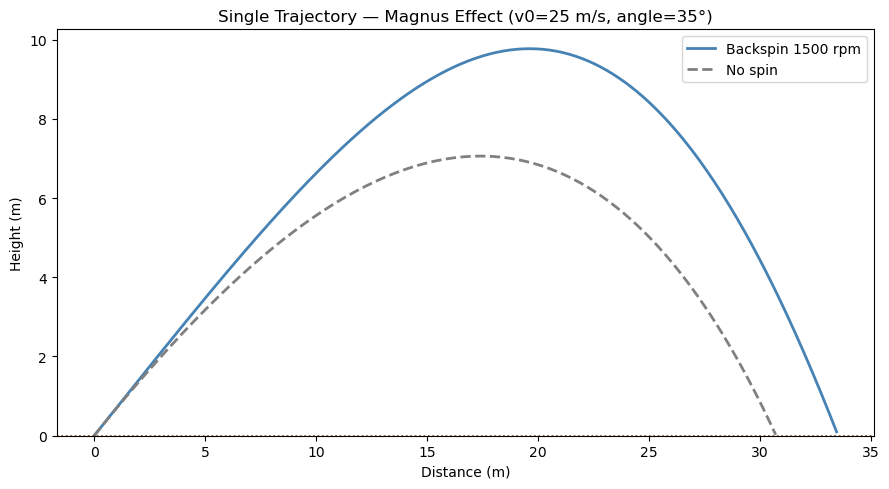

In [2]:
traj = model.simulate(launch_speed_mps=25.0, launch_angle_deg=35.0, spin_rpm=1500.0)
print(f'Range: {model.range_m(traj):.1f} m | Max height: {model.max_height(traj):.1f} m | ToF: {model.time_of_flight(traj):.2f} s')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(traj.x, traj.y, lw=2, color='steelblue', label='Backspin 1500 rpm')
traj0 = model.simulate(25.0, 35.0, spin_rpm=0.0)
ax.plot(traj0.x, traj0.y, lw=2, ls='--', color='grey', label='No spin')
ax.axhline(0, color='saddlebrown', lw=1.2, ls=':')
ax.set_ylim(bottom=0)
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Height (m)')
ax.set_title('Single Trajectory — Magnus Effect (v0=25 m/s, angle=35°)')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Trajectory family (3×3 grid)

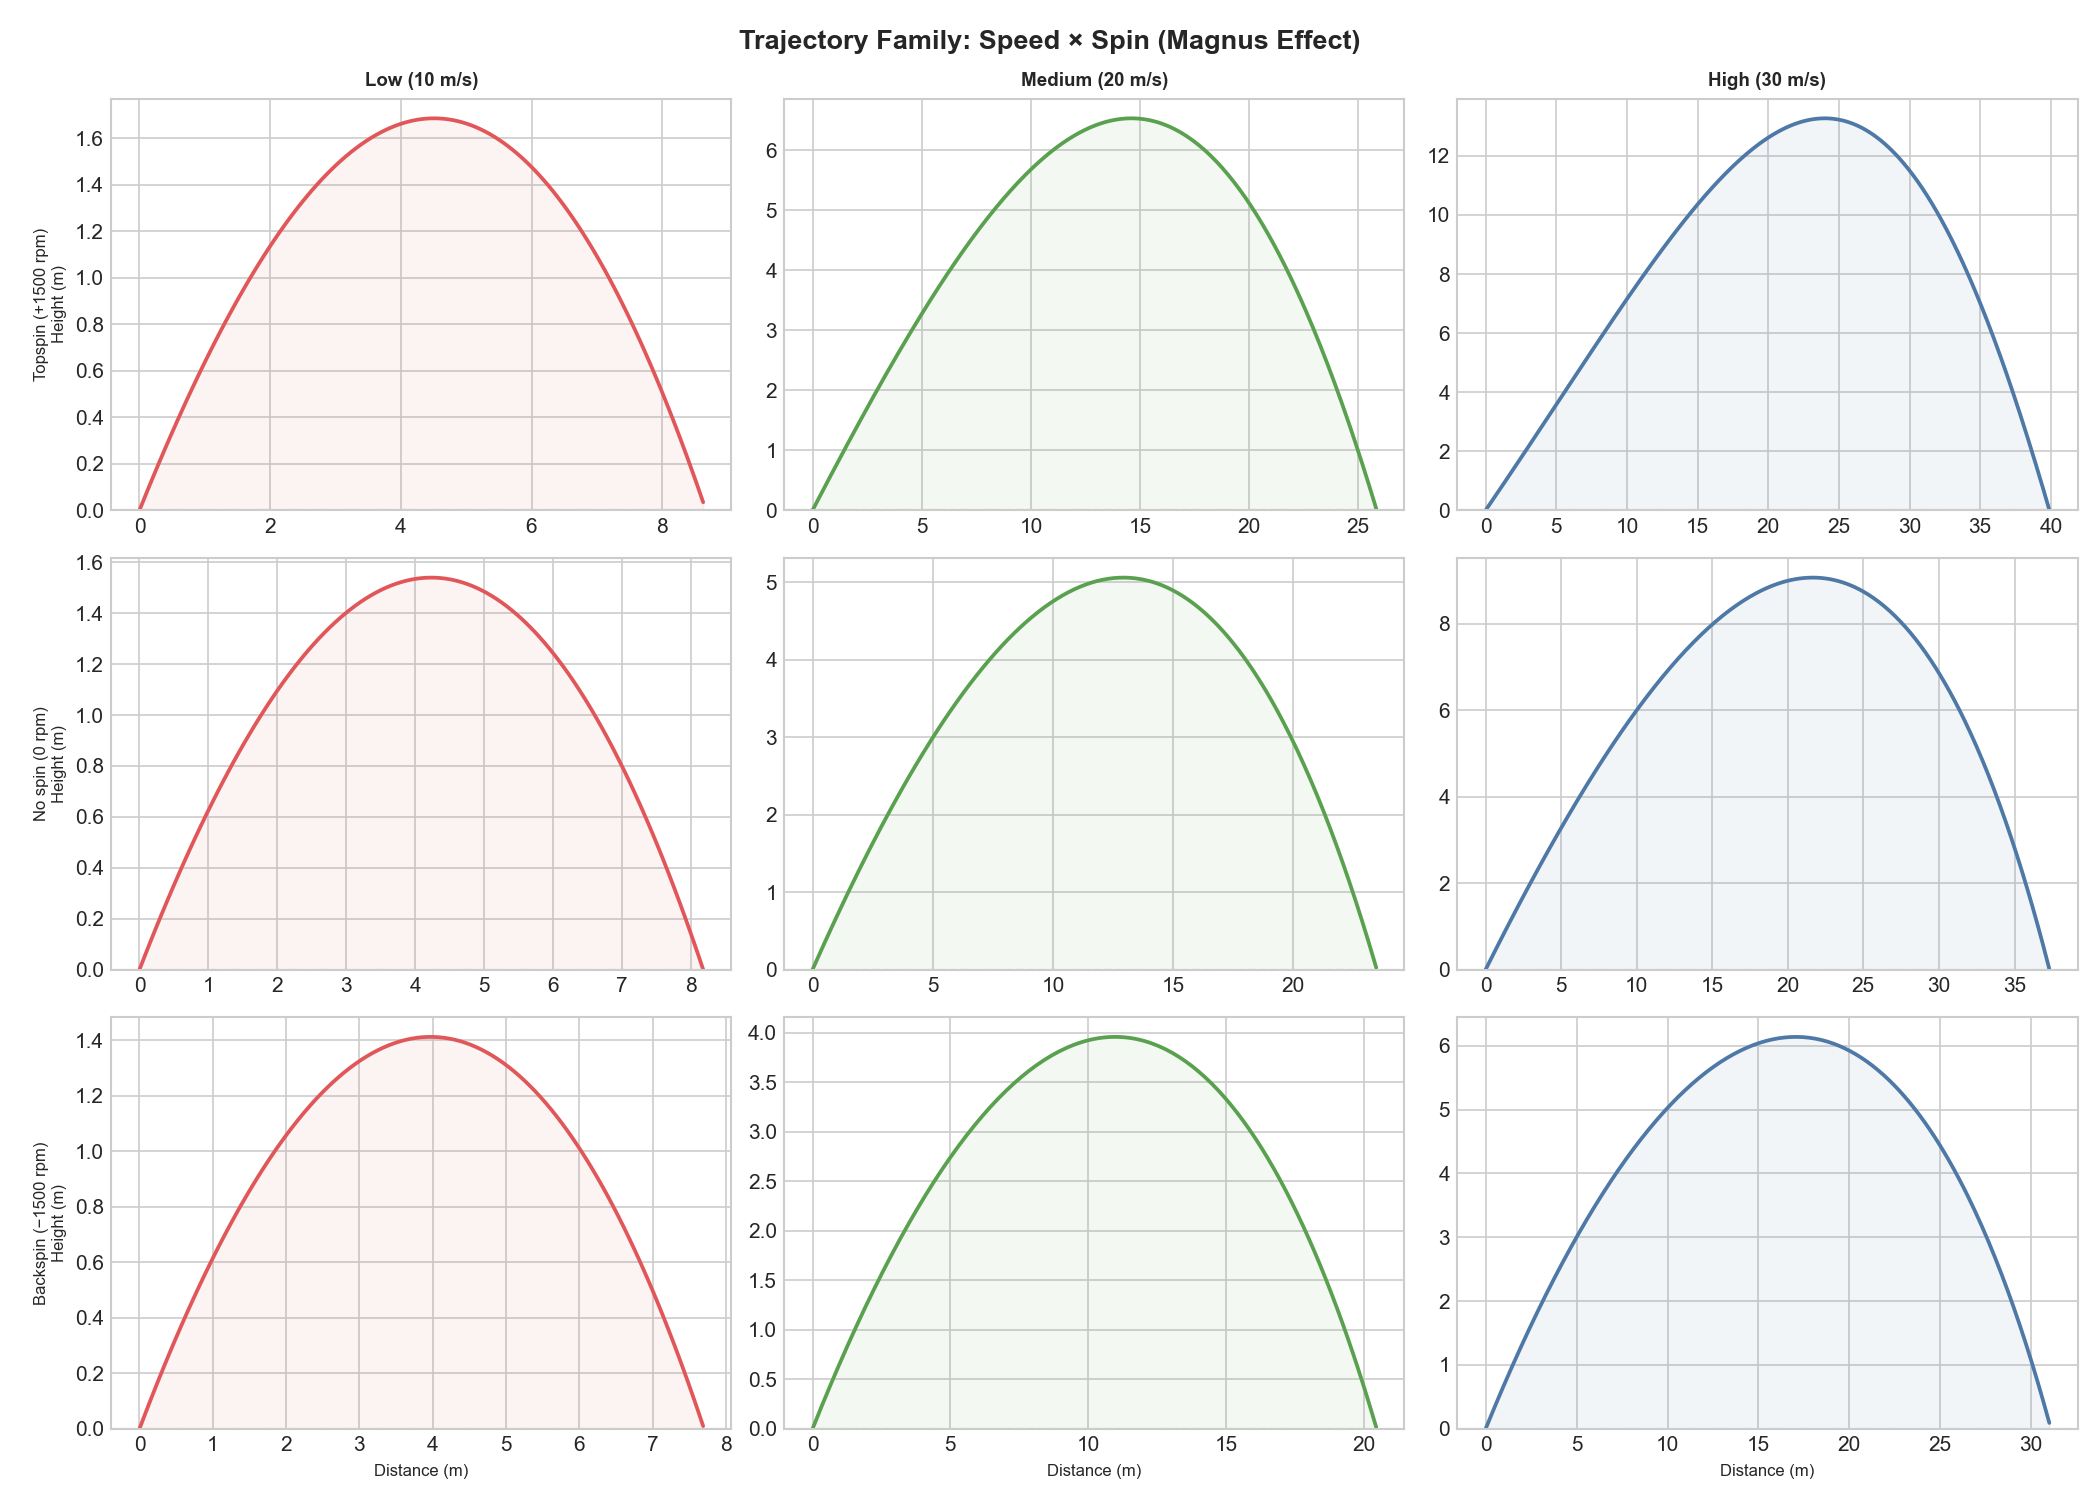

In [3]:
Path('../outputs/plots').mkdir(parents=True, exist_ok=True)
plot_trajectory_family(model, save_path=Path('../outputs/plots/trajectory_family.png'))
from IPython.display import Image
Image('../outputs/plots/trajectory_family.png', width=800)

## 3. Effect of launch speed on range

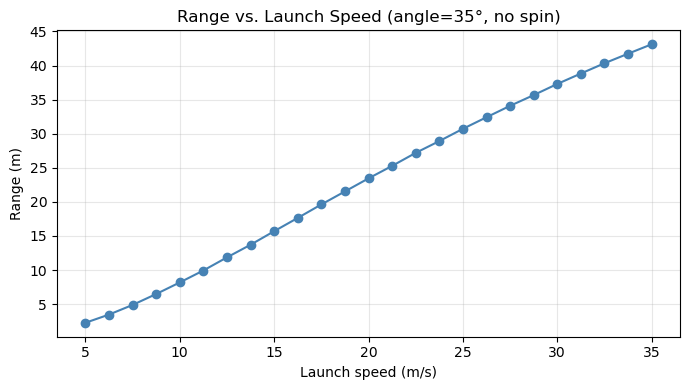

In [4]:
speeds = np.linspace(5, 35, 25)
ranges = [model.range_m(model.simulate(s, 35.0, 0.0)) for s in speeds]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(speeds, ranges, 'o-', color='steelblue')
ax.set_xlabel('Launch speed (m/s)')
ax.set_ylabel('Range (m)')
ax.set_title('Range vs. Launch Speed (angle=35°, no spin)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Magnus effect — range vs. spin RPM

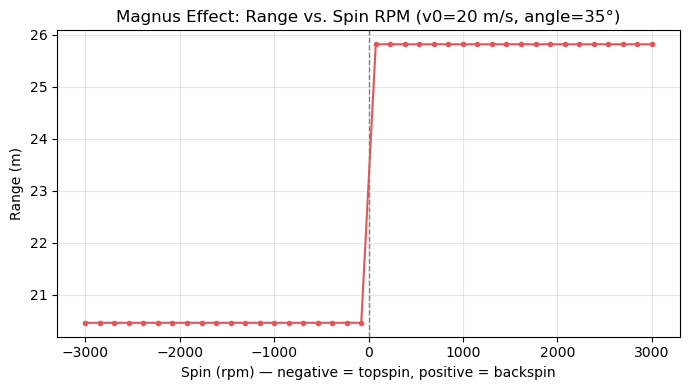

In [5]:
spins = np.linspace(-3000, 3000, 40)
ranges_spin = [model.range_m(model.simulate(20.0, 35.0, float(s))) for s in spins]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(spins, ranges_spin, 'o-', color='#e15759', ms=3)
ax.axvline(0, color='grey', lw=1, ls='--')
ax.set_xlabel('Spin (rpm) — negative = topspin, positive = backspin')
ax.set_ylabel('Range (m)')
ax.set_title('Magnus Effect: Range vs. Spin RPM (v0=20 m/s, angle=35°)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 3D shot arc

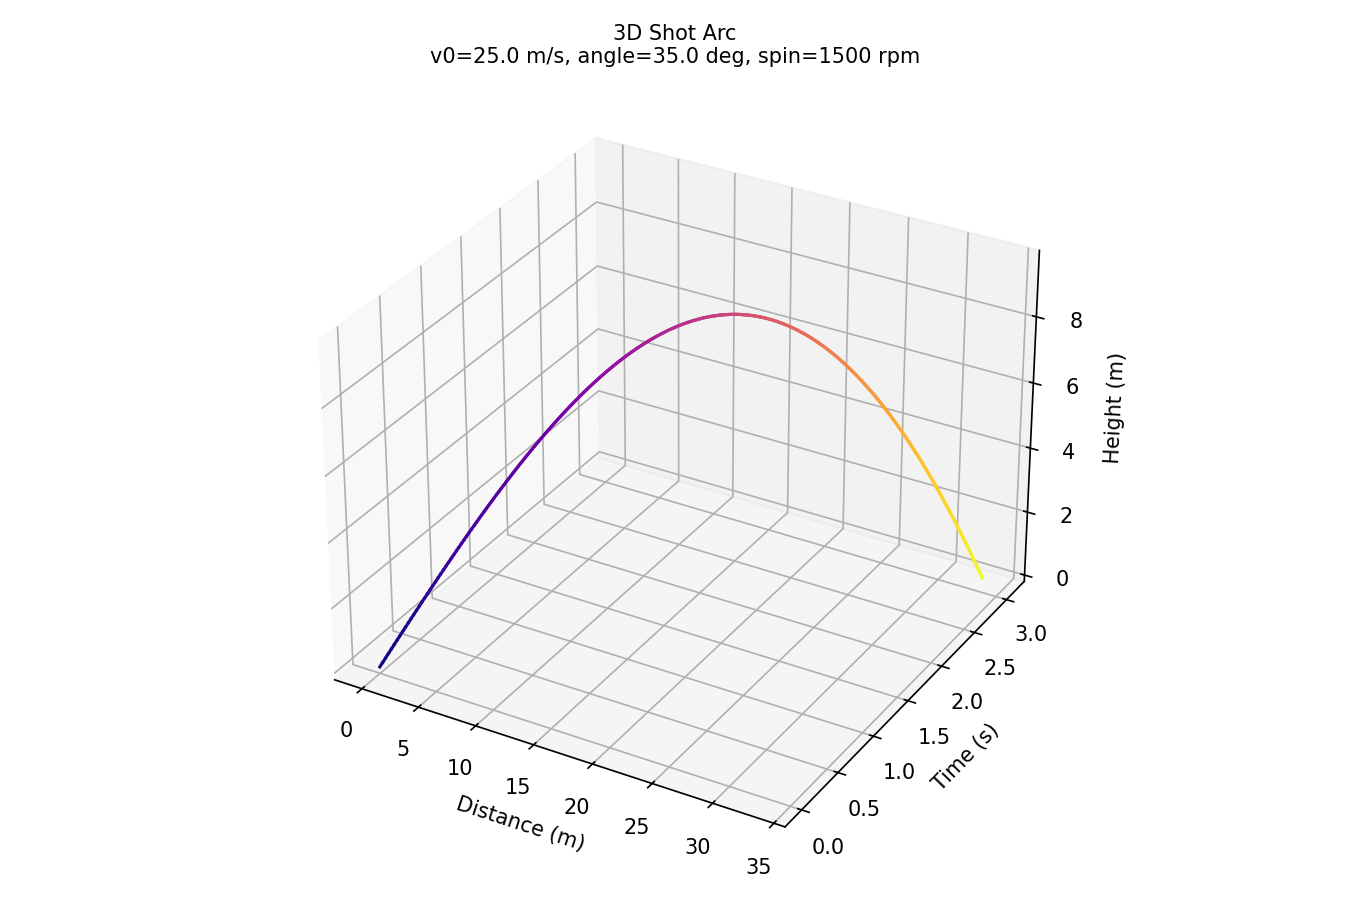

In [6]:
plot_3d_shot_arc(traj, save_path=Path('../outputs/plots/shot_arc_3d.png'))
Image('../outputs/plots/shot_arc_3d.png', width=600)